In [1]:
# Libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# just to make plots look a bit better
sns.set_style("whitegrid")

Data Inspection

In [2]:
# loading the dataset
df = pd.read_csv(r"cyberguard_raw_dataset.csv")
df.head()

,password_reuse,password_strength,password_change_freq,mfa_usage,click_unknown_links,verify_sender,report_suspicious_email,past_phishing_victim,training_completion,training_engagement,device_type,public_wifi_usage,unknown_usb_usage,social_media_oversharing,screen_lock_habit,credential_sharing,department,risk_level
0,Sometimes,"Long & random (12+ chars, mixed)",Every 1-3 months,Always,"Yes, likely",Sometimes,Ignore it,More than once,Never,Attend but forget,Company-issued & managed,Rarely,"Yes, if it looks harmless",Frequently,Always,Once,IT,Moderate
1,Never,"Long & random (12+ chars, mixed)",Every 6-12 months,Always,Never,Sometimes,Open it to check,Once,Never,"Very seriously, apply what I learn",Shared/public device,Never,Only after scanning it,Never,Always,Never,Operations,Low
2,Never,Medium (word + numbers),Never,Sometimes,"Yes, likely",Always,Delete it,NaN,Never,Skip when possible,Shared/public device,NaN,Never,Occasionally,Sometimes,Once,Other,Moderate
3,Always,Medium (word + numbers),Never,Sometimes,"Yes, likely",Always,Delete it,Once,"Yes, but over a year ago",Attend but forget,Personal device (BYOD),Rarely,"Yes, if it looks harmless",Frequently,Sometimes,Once,Sales & Marketing,Moderate
4,Never,"Long & random (12+ chars, mixed)",Every 1-3 months,Always,Never,Always,Report to IT/Security,Never,"Yes, recently (within 6 months)","Very seriously, apply what I learn",Company-issued & managed,Never,Never,Never,Always,Never,Sales & Marketing,Low


In [3]:
# last 5 rows
df.tail()

,password_reuse,password_strength,password_change_freq,mfa_usage,click_unknown_links,verify_sender,report_suspicious_email,past_phishing_victim,training_completion,training_engagement,device_type,public_wifi_usage,unknown_usb_usage,social_media_oversharing,screen_lock_habit,credential_sharing,department,risk_level
9995,Always,Medium (word + numbers),Never,Never,"Yes, likely",Never,Ignore it,More than once,Never,Skip when possible,Personal device (BYOD),Frequently,"Yes, if it looks harmless",Frequently,Sometimes,Occasionally,Other,Severe
9996,Always,Simple (name/birthdate/common word),Never,Sometimes,Rarely,Sometimes,Open it to check,Once,"Yes, but over a year ago",Skip when possible,Shared/public device,Rarely,Only after scanning it,Occasionally,Sometimes,Never,Operations,Moderate
9997,Never,"Long & random (12+ chars, mixed)",Every 1-3 months,Sometimes,Never,Sometimes,Open it to check,Never,"Yes, recently (within 6 months)",Attend but forget,Company-issued & managed,Frequently,Never,Frequently,Always,Occasionally,Sales & Marketing,Low
9998,Often,Simple (name/birthdate/common word),Never,Never,"Yes, likely",Never,Delete it,More than once,"Yes, recently (within 6 months)",Skip when possible,Personal device (BYOD),Rarely,Only after scanning it,Frequently,Never,Occasionally,Sales & Marketing,Moderate
9999,Never,"Long & random (12+ chars, mixed)",Never,Never,Rarely,Always,NaN,More than once,"Yes, recently (within 6 months)",Attend but forget,Personal device (BYOD),Rarely,"Yes, if it looks harmless",NaN,Sometimes,Never,Sales & Marketing,Moderate


In [4]:
# shape -> (rows, columns)
df.shape

(10000, 18)

In [5]:
# size -> total number of cells (rows x columns)
df.size

180000

In [6]:
# info -> column names, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   password_reuse            9846 non-null   object
 1   password_strength         9857 non-null   object
 2   password_change_freq      9849 non-null   object
 3   mfa_usage                 9857 non-null   object
 4   click_unknown_links       9841 non-null   object
 5   verify_sender             9851 non-null   object
 6   report_suspicious_email   9854 non-null   object
 7   past_phishing_victim      9852 non-null   object
 8   training_completion       9838 non-null   object
 9   training_engagement       9860 non-null   object
 10  device_type               9855 non-null   object
 11  public_wifi_usage         9852 non-null   object
 12  unknown_usb_usage         9864 non-null   object
 13  social_media_oversharing  9848 non-null   object
 14  screen_lock_habit      

In [7]:
# describe -> statistical summary , since most of our columns are categorical (MCQ answers) so for object/categorical columns
df.describe(include="object")

,password_reuse,password_strength,password_change_freq,mfa_usage,click_unknown_links,verify_sender,report_suspicious_email,past_phishing_victim,training_completion,training_engagement,device_type,public_wifi_usage,unknown_usb_usage,social_media_oversharing,screen_lock_habit,credential_sharing,department,risk_level
count,9846,9857,9849,9857,9841,9851,9854,9852,9838,9860,9855,9852,9864,9848,9854,9841,10000,10000
unique,4,3,4,3,4,3,4,3,3,3,3,3,3,3,3,3,6,4
top,Never,"Long & random (12+ chars, mixed)",Every 1-3 months,Never,Never,Always,Open it to check,Never,Never,"Very seriously, apply what I learn",Shared/public device,Never,Never,Frequently,Never,Never,Sales & Marketing,Low
freq,3265,3692,3026,3772,3338,3661,3164,3522,3574,3721,3467,3649,3697,3531,3611,3729,2490,3980


Data Cleaning

In [8]:
# check how many missing values each column has
df.isnull().sum()

password_reuse              154
password_strength           143
password_change_freq        151
mfa_usage                   143
click_unknown_links         159
verify_sender               149
report_suspicious_email     146
past_phishing_victim        148
training_completion         162
training_engagement         140
device_type                 145
public_wifi_usage           148
unknown_usb_usage           136
social_media_oversharing    152
screen_lock_habit           146
credential_sharing          159
department                    0
risk_level                    0
dtype: int64

In [9]:
# dropping Null containing rows because (each column showing ~9,885–9,923 non-null out of 10,000, roughly 1–2% missing per column)
df = df.dropna()
df.shape

(8400, 18)

In [10]:
df.shape

(8400, 18)

Handle Duplicates

In [11]:
df.duplicated().sum()

np.int64(347)

In [12]:
# dropping duplicate rows 
df = df.drop_duplicates()

In [13]:
df.shape

(8053, 18)

In [14]:
# reset index after dropping rows so it's continuous again (0,1,2,3...)
df = df.reset_index(drop=True)

Data Analysis - (Group by, Pivot by) 

In [15]:
# does risk level distribution differ across departments?
df.groupby("department")["risk_level"].value_counts(normalize=True).round(2)

department         risk_level
Finance            Low           0.35
                   Moderate      0.29
                   High          0.22
                   Severe        0.14
HR                 Low           0.36
                   Moderate      0.31
                   High          0.22
                   Severe        0.11
IT                 Low           0.47
                   Moderate      0.30
                   High          0.18
                   Severe        0.06
Operations         Low           0.42
                   Moderate      0.29
                   High          0.20
                   Severe        0.09
Other              Low           0.42
                   Moderate      0.31
                   High          0.19
                   Severe        0.08
Sales & Marketing  Low           0.38
                   Moderate      0.31
                   High          0.20
                   Severe        0.11
Name: proportion, dtype: float64

IT has the highest share of Low risk employees (47%) and the lowest share of Severe risk (6%), likely reflecting stronger security awareness

Finance and HR show the highest Severe risk proportions (14% and 11%)

In [16]:
# does MFA usage relate to risk level?
df.groupby("mfa_usage")["risk_level"].value_counts(normalize=True).round(2)

mfa_usage  risk_level
Always     Low           0.67
           Moderate      0.26
           High          0.07
           Severe        0.01
Never      High          0.34
           Moderate      0.29
           Severe        0.23
           Low           0.14
Sometimes  Moderate      0.39
           Low           0.39
           High          0.19
           Severe        0.03
Name: proportion, dtype: float64

MFA usage has a strong relationship with risk level. 

Employees who Always use MFA are overwhelmingly Low risk (67%) with almost no Severe cases (1%). 

Employees who Never use MFA show a completely reversed pattern — only 14% Low risk, and 23% Severe. This confirms `mfa_usage` is one 
of the strongest individual predictors of risk in this dataset.

In [17]:
# Pivot Table: Department vs Risk Level (counts)
pivot1 = df.pivot_table(index="department", columns="risk_level", values="mfa_usage", aggfunc="count")
pivot1

risk_level,High,Low,Moderate,Severe
department,,,,
Finance,282,444,375,173
HR,180,292,247,85
IT,205,549,350,65
Operations,313,644,448,145
Other,237,524,394,105
Sales & Marketing,403,763,613,217


IT has the highest Low-risk count (549) relative to its Severe count (65), 

while Finance and HR show a comparatively higher 
share of High/Severe counts relative to their total size.

### Exploratory Data Analysis
Univariate 

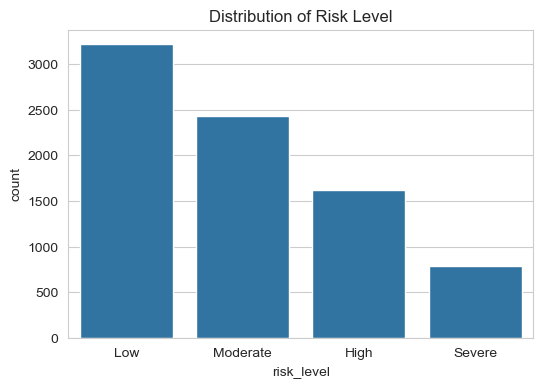

In [18]:
# Distribution of Risk Level
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="risk_level", order=["Low","Moderate","High","Severe"])
plt.title("Distribution of Risk Level")
plt.show()

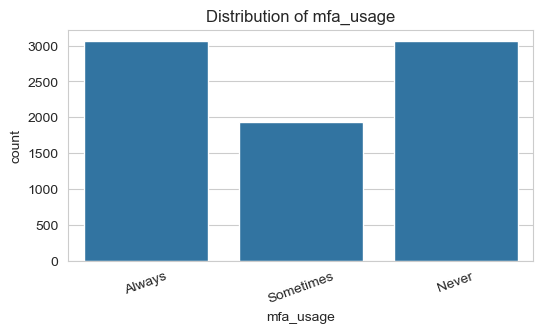

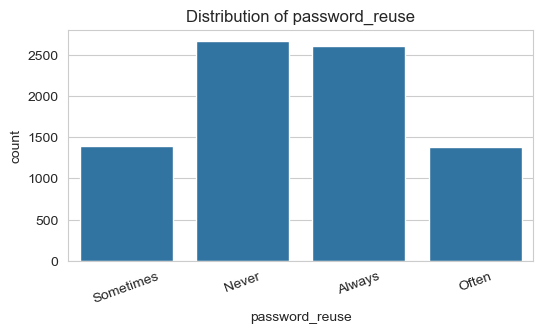

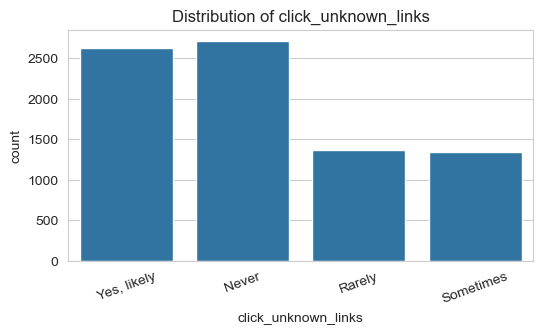

In [19]:
# just looping through a few important columns to see how answers are spread
cols_to_check = ["mfa_usage", "password_reuse", "click_unknown_links"]

for col in cols_to_check:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=20)
    plt.show()

Bivariate: Feature vs Target

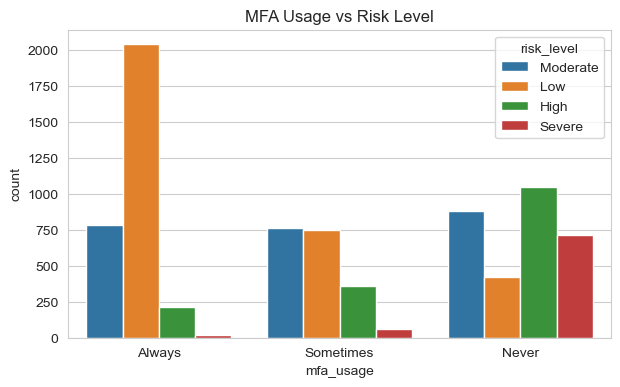

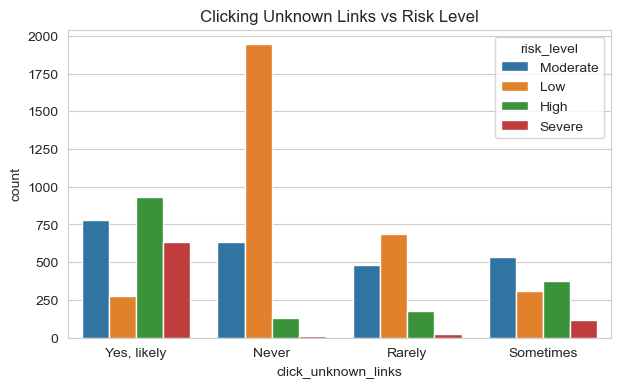

In [20]:
# how does each feature's answer relate to risk_level?
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="mfa_usage", hue="risk_level")
plt.title("MFA Usage vs Risk Level")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="click_unknown_links", hue="risk_level")
plt.title("Clicking Unknown Links vs Risk Level")
plt.show()

### Encoding
Most of our columns are ordered MCQ answers (Never < Sometimes < Often < Always), so we use `Ordinal Encoding` with a defined order instead of random label encoding. `department and device_type` are not ordered, so we use `One-Hot Encoding` for those.

In [21]:
from sklearn.preprocessing import OrdinalEncoder

# defining the correct real-world order for each ordinal column
order_password_reuse = ["Never", "Sometimes", "Often", "Always"]
order_password_strength = ["Simple (name/birthdate/common word)", "Medium (word + numbers)", "Long & random (12+ chars, mixed)"]
order_password_change_freq = ["Never", "Rarely", "Every 6-12 months", "Every 1-3 months"]
order_mfa_usage = ["Never", "Sometimes", "Always"]
order_click_unknown_links = ["Never", "Rarely", "Sometimes", "Yes, likely"]
order_verify_sender = ["Never", "Sometimes", "Always"]
order_report_suspicious_email = ["Report to IT/Security", "Delete it", "Ignore it", "Open it to check"]
order_past_phishing_victim = ["Never", "Once", "More than once"]
order_training_completion = ["Yes, recently (within 6 months)", "Yes, but over a year ago", "Never"]
order_training_engagement = ["Very seriously, apply what I learn", "Attend but forget", "Skip when possible"]
order_public_wifi_usage = ["Never", "Rarely", "Frequently"]
order_unknown_usb_usage = ["Never", "Only after scanning it", "Yes, if it looks harmless"]
order_social_media_oversharing = ["Never", "Occasionally", "Frequently"]
order_screen_lock_habit = ["Always", "Sometimes", "Never"]
order_credential_sharing = ["Never", "Once", "Occasionally"]


In [22]:
ordinal_cols = ["password_reuse","password_strength","password_change_freq","mfa_usage",
                "click_unknown_links","verify_sender","report_suspicious_email",
                "past_phishing_victim","training_completion","training_engagement",
                "public_wifi_usage","unknown_usb_usage","social_media_oversharing",
                "screen_lock_habit","credential_sharing"]

In [23]:

ordinal_categories = [order_password_reuse, order_password_strength, order_password_change_freq,
                      order_mfa_usage, order_click_unknown_links, order_verify_sender,
                      order_report_suspicious_email, order_past_phishing_victim,
                      order_training_completion, order_training_engagement,
                      order_public_wifi_usage, order_unknown_usb_usage,
                      order_social_media_oversharing, order_screen_lock_habit,
                      order_credential_sharing]

Apply Ordinal Encoding - on 15 columns

In [24]:
df_encoded = df.copy()

ordinal_encoding = OrdinalEncoder(categories=ordinal_categories)
df_encoded[ordinal_cols] = ordinal_encoding.fit_transform(df_encoded[ordinal_cols])

df_encoded[ordinal_cols].head()

,password_reuse,password_strength,password_change_freq,mfa_usage,click_unknown_links,verify_sender,report_suspicious_email,past_phishing_victim,training_completion,training_engagement,public_wifi_usage,unknown_usb_usage,social_media_oversharing,screen_lock_habit,credential_sharing
0,1.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,0.0,1.0
1,0.0,2.0,2.0,2.0,0.0,1.0,3.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.0,1.0,0.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0
3,0.0,2.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,1.0,2.0


In [25]:
df_encoded[["device_type", "department"]].head()

,device_type,department
0,Company-issued & managed,IT
1,Shared/public device,Operations
2,Personal device (BYOD),Sales & Marketing
3,Company-issued & managed,Sales & Marketing
4,Company-issued & managed,Finance


In [26]:
df_encoded[["device_type", "department"]]

,device_type,department
0,Company-issued & managed,IT
1,Shared/public device,Operations
2,Personal device (BYOD),Sales & Marketing
3,Company-issued & managed,Sales & Marketing
4,Company-issued & managed,Finance
...,...,...
8048,Shared/public device,Operations
8049,Personal device (BYOD),IT
8050,Personal device (BYOD),Sales & Marketing
8051,Personal device (BYOD),Other


Now implementing one hot encoding on these 2 columns 

In [27]:
df_encoded["device_type"].value_counts()

device_type
Shared/public device        2815
Company-issued & managed    2758
Personal device (BYOD)      2480
Name: count, dtype: int64

In [28]:
df_encoded["department"].value_counts()

department
Sales & Marketing    1996
Operations           1550
Finance              1274
Other                1260
IT                   1169
HR                    804
Name: count, dtype: int64

In [29]:
df_encoded = pd.get_dummies(df_encoded, columns=["device_type", "department"], drop_first=False, dtype=int)
df_encoded.head()

,password_reuse,password_strength,password_change_freq,mfa_usage,click_unknown_links,verify_sender,report_suspicious_email,past_phishing_victim,training_completion,training_engagement,...,risk_level,device_type_Company-issued & managed,device_type_Personal device (BYOD),device_type_Shared/public device,department_Finance,department_HR,department_IT,department_Operations,department_Other,department_Sales & Marketing
0,1.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,...,Moderate,1,0,0,0,0,1,0,0,0
1,0.0,2.0,2.0,2.0,0.0,1.0,3.0,1.0,2.0,0.0,...,Low,0,0,1,0,0,0,1,0,0
2,3.0,1.0,0.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,...,Moderate,0,1,0,0,0,0,0,0,1
3,0.0,2.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,...,Low,1,0,0,0,0,0,0,0,1
4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,...,Moderate,1,0,0,1,0,0,0,0,0


Only target column left for encoding so now encoding `risk_level` 

In [30]:
# Manual Encoding 
risk_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Severe": 3
}

df_encoded["risk_level"] = df_encoded["risk_level"].map(risk_map)
df_encoded["risk_level"].value_counts()

risk_level
0    3216
1    2427
2    1620
3     790
Name: count, dtype: int64

In [31]:
df_encoded

,password_reuse,password_strength,password_change_freq,mfa_usage,click_unknown_links,verify_sender,report_suspicious_email,past_phishing_victim,training_completion,training_engagement,...,risk_level,device_type_Company-issued & managed,device_type_Personal device (BYOD),device_type_Shared/public device,department_Finance,department_HR,department_IT,department_Operations,department_Other,department_Sales & Marketing
0,1.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,...,1,1,0,0,0,0,1,0,0,0
1,0.0,2.0,2.0,2.0,0.0,1.0,3.0,1.0,2.0,0.0,...,0,0,0,1,0,0,0,1,0,0
2,3.0,1.0,0.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,1
3,0.0,2.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,1
4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,...,1,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8048,0.0,2.0,1.0,2.0,1.0,0.0,2.0,2.0,2.0,0.0,...,1,0,0,1,0,0,0,1,0,0
8049,3.0,2.0,2.0,2.0,3.0,0.0,2.0,0.0,1.0,2.0,...,2,0,1,0,0,0,1,0,0,0
8050,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,1
8051,3.0,1.0,0.0,0.0,3.0,0.0,2.0,2.0,2.0,2.0,...,3,0,1,0,0,0,0,0,1,0


### Multivarite analysis (we skipped earlier because Standard correlation heatmaps mathematically require numeric data and cannot process raw categorical text strings directly.)

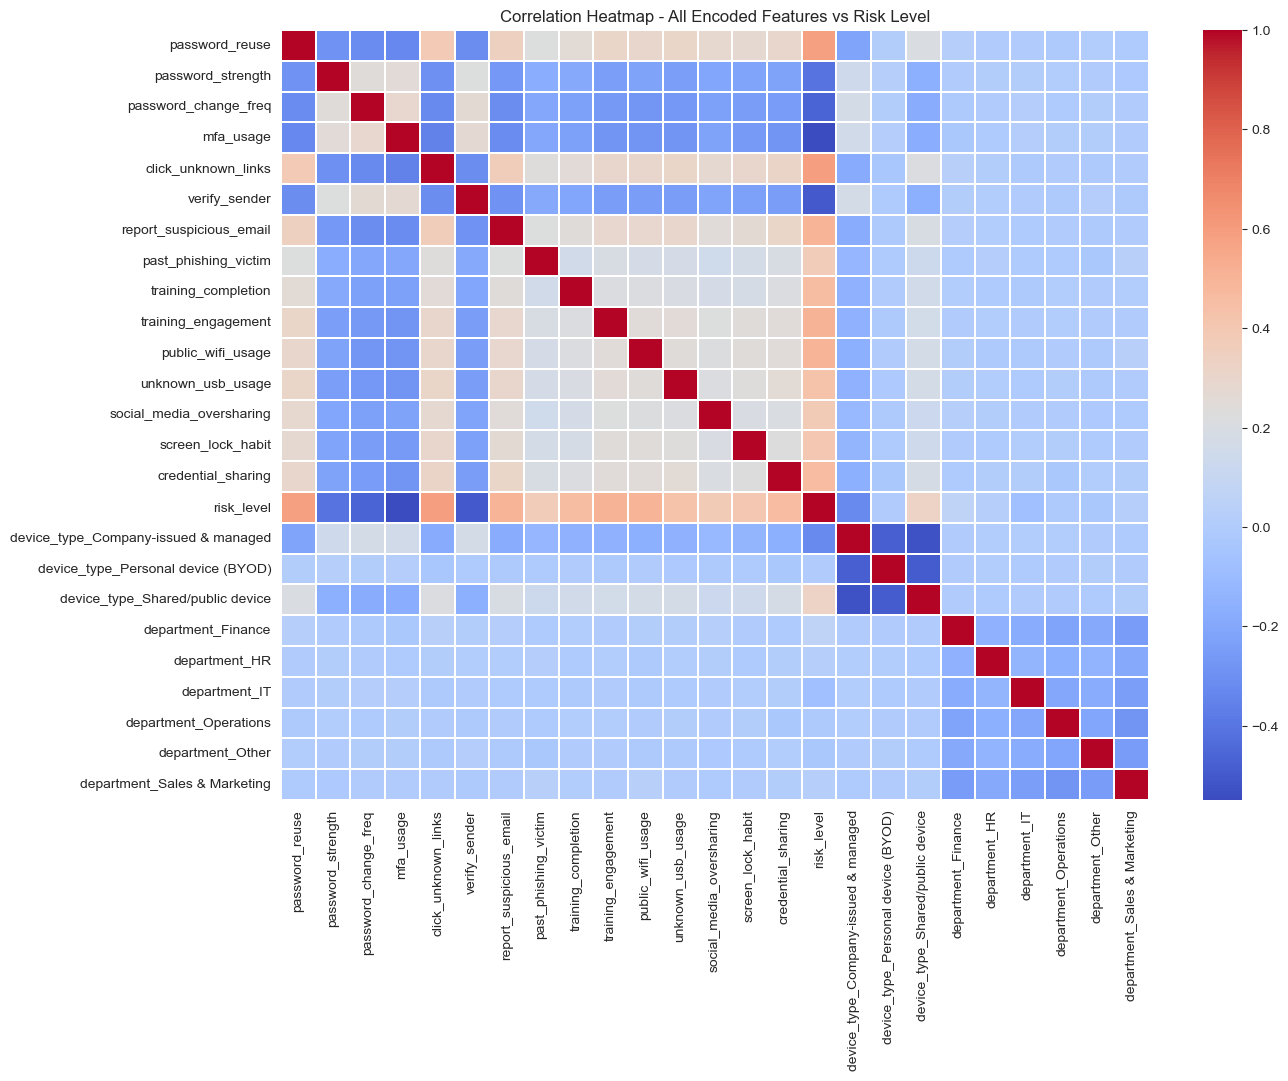

In [32]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=False, linewidths=0.3)
plt.title("Correlation Heatmap - All Encoded Features vs Risk Level")
plt.show()

In [33]:
# easier to read than the full heatmap - just target correlations, ranked
target_corr = df_encoded.corr()["risk_level"].drop("risk_level").sort_values(ascending=False)
target_corr

click_unknown_links                     0.590849
password_reuse                          0.585872
training_engagement                     0.509052
report_suspicious_email                 0.503685
public_wifi_usage                       0.503617
credential_sharing                      0.462965
training_completion                     0.456063
unknown_usb_usage                       0.430217
screen_lock_habit                       0.402016
social_media_oversharing                0.379941
past_phishing_victim                    0.372271
device_type_Shared/public device        0.323967
department_Finance                      0.063698
department_HR                           0.024774
department_Sales & Marketing            0.022503
device_type_Personal device (BYOD)     -0.000290
department_Operations                  -0.011987
department_Other                       -0.025554
department_IT                          -0.074884
device_type_Company-issued & managed   -0.325249
password_strength   

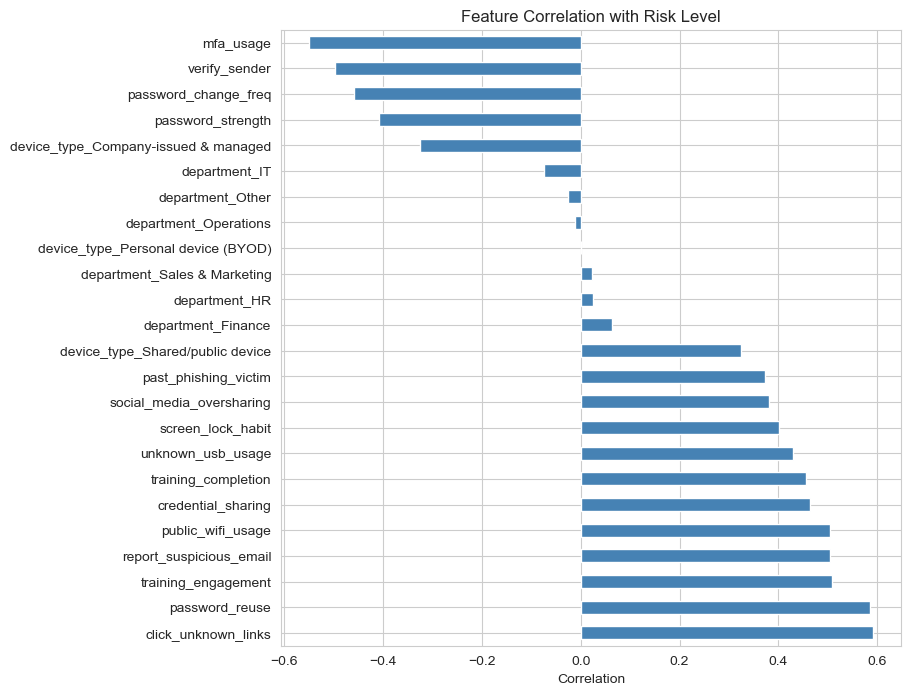

In [34]:
plt.figure(figsize=(8,8))
target_corr.plot(kind="barh", color="steelblue")
plt.title("Feature Correlation with Risk Level")
plt.xlabel("Correlation")
plt.show()

### Statistical Test for Feature Selection (Chi-Square)

Since our target is categorical and our original features are categorical too, Chi-Square test is the right basic test to check which features are actually related to risk_level.

In [35]:
from sklearn.feature_selection import chi2


X = df_encoded.drop("risk_level", axis=1)
y = df_encoded["risk_level"]

# 2. Calculate Chi2 scores and p-values 
chi_scores, p_values = chi2(X, y)

# 3. Results to show in a (DataFrame) 
chi_df = pd.DataFrame(
    {"Feature": X.columns, "Chi2_Score": chi_scores, "P_Value": p_values}
).sort_values(by="P_Value")

chi_df


,Feature,Chi2_Score,P_Value
0,password_reuse,2924.358995,0.000000e+00
2,password_change_freq,1654.953804,0.000000e+00
3,mfa_usage,1861.963521,0.000000e+00
4,click_unknown_links,3061.868228,0.000000e+00
5,verify_sender,1445.600849,0.000000e+00
6,report_suspicious_email,2113.673002,0.000000e+00
10,public_wifi_usage,1550.821464,0.000000e+00
9,training_engagement,1580.459489,0.000000e+00
14,credential_sharing,1324.703840,6.420116e-287
8,training_completion,1217.139802,1.400931e-263



Although the Chi-Square test identifies a few one-hot encoded `department` columns as statistically insignificant but we are ` not dropping them ` for the following structural and deployment reasons:

1. `Information Integrity (Multicollinearity Avoidance)`: One-hot encoded columns collectively represent a single real-world feature (`department`). Selectively dropping categories creates a mathematical bug where different dropped categories (e.g., HR vs. Operations) become numerically indistinguishable ($0$ across all remaining columns) to the model.

2. ` UI Deployment (Streamlit Consistency)`: Keeping the complete set ensures our downstream Streamlit app's input fields map seamlessly to the pipeline without breaking the feature encoding pipeline when a user selects a "dropped" department.


### Train - Test Split

In [37]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("risk_level", axis=1)
y = df_encoded["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X Train shape:", X_train.shape)
print("X Test shape:", X_test.shape)
print("y Train shape:",y_train.shape)
print("y Test shape:",y_test.shape)

X Train shape: (6442, 24)
X Test shape: (1611, 24)
y Train shape: (6442,)
y Test shape: (1611,)


### Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Fitting — Logistic Regression, KNN, Random Forest, XGBoost

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Logistic Regression

In [40]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print()
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7877094972067039

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       643
           1       0.71      0.70      0.70       486
           2       0.71      0.73      0.72       324
           3       0.83      0.79      0.81       158

    accuracy                           0.79      1611
   macro avg       0.78      0.78      0.78      1611
weighted avg       0.79      0.79      0.79      1611



KNN

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print()
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.6741154562383612

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       643
           1       0.59      0.45      0.52       486
           2       0.55      0.48      0.51       324
           3       0.62      0.78      0.69       158

    accuracy                           0.67      1611
   macro avg       0.63      0.66      0.64      1611
weighted avg       0.66      0.67      0.66      1611



Random Forest

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8106765983860956

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       643
           1       0.75      0.74      0.75       486
           2       0.73      0.74      0.73       324
           3       0.88      0.72      0.79       158

    accuracy                           0.81      1611
   macro avg       0.81      0.78      0.79      1611
weighted avg       0.81      0.81      0.81      1611



XGBoost

In [43]:
xgb_model = XGBClassifier(random_state=42, eval_metric="mlogloss")
xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.813780260707635
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       643
           1       0.75      0.75      0.75       486
           2       0.73      0.74      0.74       324
           3       0.86      0.78      0.82       158

    accuracy                           0.81      1611
   macro avg       0.81      0.80      0.80      1611
weighted avg       0.81      0.81      0.81      1611



In [44]:
results = {
    "Model": ["Logistic Regression", "KNN", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
    ],
    "Precision": [
        precision_score(y_test, log_pred, average="weighted"),
        precision_score(y_test, knn_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, xgb_pred, average="weighted"),
    ],
    "Recall": [
        recall_score(y_test, log_pred, average="weighted"),
        recall_score(y_test, knn_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, xgb_pred, average="weighted"),
    ],
    "F1 Score": [
        f1_score(y_test, log_pred, average="weighted"),
        f1_score(y_test, knn_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted"),
    ],
}

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.813780,0.813953,0.813780,0.813699
1,Random Forest,0.810677,0.810506,0.810677,0.809654
2,Logistic Regression,0.787709,0.787073,0.787709,0.787242
3,KNN,0.674115,0.659463,0.674115,0.660317


While **XGBoost wins the race**, it leads Random Forest by a very narrow margin (~0.3% accuracy); therefore, we are applying **hyperparameter tuning** specifically to XGBoost to maximize its performance and widen the gap

Hyperparameter Tuning for XGBoost

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_grid=param_grid,
    cv=3,                # 3-fold cross validation, keeps it quick
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best CV Accuracy: 0.8315734107933435


Evaluate the tuned model on test data

In [46]:
best_xgb = grid_search.best_estimator_

tuned_pred = best_xgb.predict(X_test_scaled)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, tuned_pred))
print(classification_report(y_test, tuned_pred))

Tuned XGBoost Accuracy: 0.8386095592799503
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       643
           1       0.79      0.78      0.78       486
           2       0.77      0.79      0.78       324
           3       0.87      0.79      0.83       158

    accuracy                           0.84      1611
   macro avg       0.83      0.82      0.83      1611
weighted avg       0.84      0.84      0.84      1611



Add it to the comparison table

In [47]:
new_row = pd.DataFrame([{
    "Model": "XGBoost (Tuned)",
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, average="weighted"),
    "Recall": recall_score(y_test, tuned_pred, average="weighted"),
    "F1 Score": f1_score(y_test, tuned_pred, average="weighted"),
}])

results_df = pd.concat([results_df, new_row], ignore_index=True).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost (Tuned),0.838610,0.838696,0.838610,0.838404
1,XGBoost,0.813780,0.813953,0.813780,0.813699
2,Random Forest,0.810677,0.810506,0.810677,0.809654
3,Logistic Regression,0.787709,0.787073,0.787709,0.787242
4,KNN,0.674115,0.659463,0.674115,0.660317


## Final Model Selection

Four models were trained and compared for this multi-class risk classification 
problem: Logistic Regression, K-Nearest Neighbors, Random Forest, and XGBoost. 

XGBoost outperformed the other models even in its default configuration 
(81.4% accuracy), and after hyperparameter tuning via GridSearchCV 
(tuning `n_estimators`, `max_depth`, and `learning_rate` with 3-fold 
cross-validation), accuracy improved to **83.9%**, along with corresponding 
gains in precision, recall, and F1-score.

Random Forest performed closely behind XGBoost, while Logistic Regression 
gave a reasonable baseline given the categorical nature of the data. KNN 
performed noticeably worse, likely due to the high-dimensional, mostly 
binary/ordinal feature space after encoding, which doesn't suit 
distance-based algorithms well.

**Final model chosen for deployment: Tuned XGBoost Classifier**, based on 
its consistently best performance across all four evaluation metrics. 

# Most critical task - Moving out ML model to production from this notebook

Problem:

Until now, your trained model, encoder, and scaler only existed inside your Jupyter notebook's temporary memory (RAM). The moment you close the notebook or restart the kernel, everything will disappear. Since a Streamlit app is a completely separate Python program, it cannot access your notebook's memory. So the question was: "How do we move a trained model out of the notebook and into another program?"

Solution:

You can use joblib library and in it joblib.dump() function saves any trained Python object (like a model, encoder, or scaler) by "freezing" it into a .pkl file on your hard drive. Later, any other Python program can use joblib.load() to bring that exact object back to life instantly—without needing to train it again.

In [48]:
import joblib

Save the trained model

In [49]:
joblib.dump(best_xgb, "risk_model.pkl")
print("Model saved!")

Model saved!


Save the Ordinal Encoder (used for the 15 ordered MCQ columns)

In [50]:
joblib.dump(ordinal_encoding, "ordinal_encoder.pkl")
print("Ordinal encoder saved!")

Ordinal encoder saved!


Save the Scaler

In [51]:
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved!")

Scaler saved!


Save the exact column order and one-hot columns

In [52]:
# save the exact list of ordinal columns (in the order the encoder expects them)
joblib.dump(ordinal_cols, "ordinal_cols.pkl")

# save the exact column order the model was trained on
model_columns = X_train.columns.tolist()
joblib.dump(model_columns, "model_columns.pkl")

print("Column reference files saved!")
print("Total columns model expects:", len(model_columns))

Column reference files saved!
Total columns model expects: 24


Save the risk_map (so we can also reverse it later, i.e. number → label)

In [53]:
risk_map = {"Low": 0, "Moderate": 1, "High": 2, "Severe": 3}
reverse_risk_map = {v: k for k, v in risk_map.items()}

joblib.dump(risk_map, "risk_map.pkl")
joblib.dump(reverse_risk_map, "reverse_risk_map.pkl")

print("Risk maps saved!")

Risk maps saved!
